In [2]:
from azureml.core import Workspace, Dataset, Datastore

subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "researcher_data")

# تعریف Dataset از مسیر
dataset = Dataset.File.from_files(path=(datastore,'Zahra/032026/Xgboost_OOT/MDPS/ARF/Evalutation'))

# گرفتن لیست فایل‌ها
file_paths = dataset.to_path()

# نمایش
for path in file_paths:
    print(path)


Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'to_path'}
{'infer_column_types': 'False', 'activity': 'to_path', 'activityApp': 'FileDataset'}
/evaluate_finetune.yaml
/metrics.csv
/predictions.csv
/xgboost.yaml
/feature_importance/fold_1.csv
/feature_importance/fold_2.csv
/feature_importance/fold_3.csv
/feature_importance/fold_4.csv
/feature_importance/fold_5.csv


In [3]:
import numpy as np

# ---------- Midrank ----------
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


# ---------- Fast DeLong ----------
def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    pos_scores = predictions_sorted_transposed[:, :m]
    neg_scores = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r] = compute_midrank(pos_scores[r])
        ty[r] = compute_midrank(neg_scores[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tx.sum(axis=1) / (m * n) - (m + 1.) / (2. * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


# ---------- AUC + STD via DeLong ----------
def delong_roc_variance(y_true, y_pred):

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred)

    assert set(np.unique(y_true)) == {0,1}

    # مرتب‌سازی بر اساس label (مثبت‌ها اول)
    order = np.argsort(-y_true)
    y_true = y_true[order]
    y_pred = y_pred[order]

    label_1_count = int(np.sum(y_true))

    preds = y_pred.reshape(1, -1)

    aucs, delongcov = fastDeLong(preds, label_1_count)

    auc = aucs[0]

    # اگر covariance scalar بود
    auc_var = delongcov if np.ndim(delongcov) == 0 else delongcov[0,0]

    auc_std = np.sqrt(auc_var)

    return auc, auc_std

from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_auc(y_true, y_score, n_bootstraps=2000, random_seed=42):

    rng = np.random.RandomState(random_seed)
    bootstrapped_scores = []

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_score), len(y_score))
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    auc_mean = roc_auc_score(y_true, y_score)
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    auc_std = np.std(sorted_scores)

    return auc_mean, auc_std, ci_lower, ci_upper


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


def plot_cv_roc(df, experiment_name, outcome_name, save_path=None):

    fold_cols = [
        "fold_1_probas",
        "fold_2_probas",
        "fold_3_probas",
        "fold_4_probas",
        "fold_5_probas"
    ]

    y_true = df["target"].astype(int)

    mean_fpr = np.linspace(0, 1, 300)
    tprs = []
    aucs = []

    plt.figure(figsize=(7, 6))
    colors = plt.cm.tab10.colors

    for i, col in enumerate(fold_cols):

        y_score = df[col]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

        plt.plot(
            fpr,
            tpr,
            color=colors[i],
            lw=1.5,
            alpha=0.8,
            label=f"Fold {i+1} (AUC = {roc_auc:.3f})"
        )

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    mean_tpr[-1] = 1.0

    plt.plot(
        mean_fpr,
        mean_tpr,
        color="black",
        lw=2.5,
        label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})"
    )

    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        color="grey",
        alpha=0.2,
        label="±1 SD"
    )

    # Random baseline
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", lw=1)

    plt.xlim([0, 1])
    plt.ylim([0, 1.05])

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    

    plt.title(
        f"ROC Curve for {outcome_name} Prediction ({experiment_name})",
        fontsize=13
    )

    plt.legend(loc="lower right", frameon=True)
    plt.grid(alpha=0.25)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


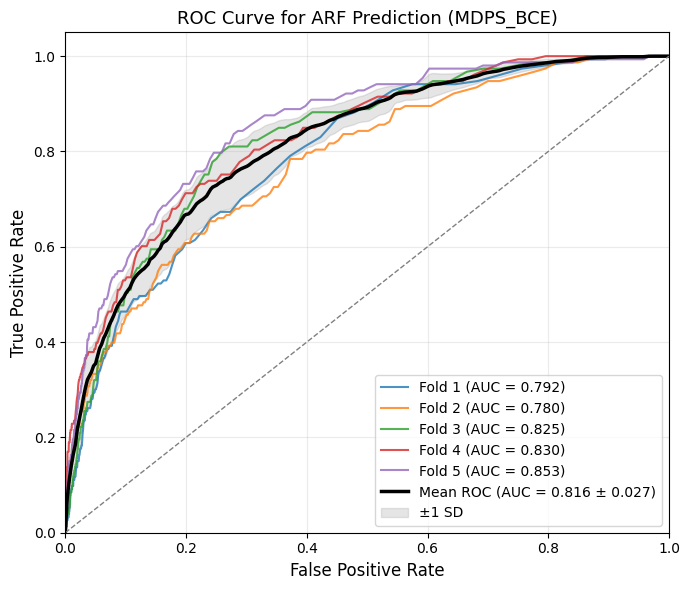

In [32]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/CoreBehrt_OOT/MDPS/3_Holdout/ARF/Predictions_BCE/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDPS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDPS, "MDPS_BCE", "ARF")

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


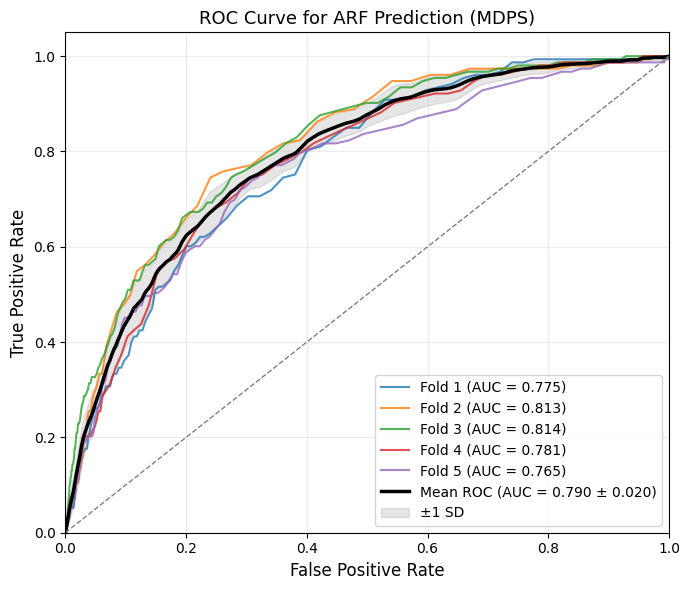

In [29]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/CoreBehrt_OOT/MDPS/3_Holdout/ARF/Predictions/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDPS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDPS, "MDPS", "ARF")

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


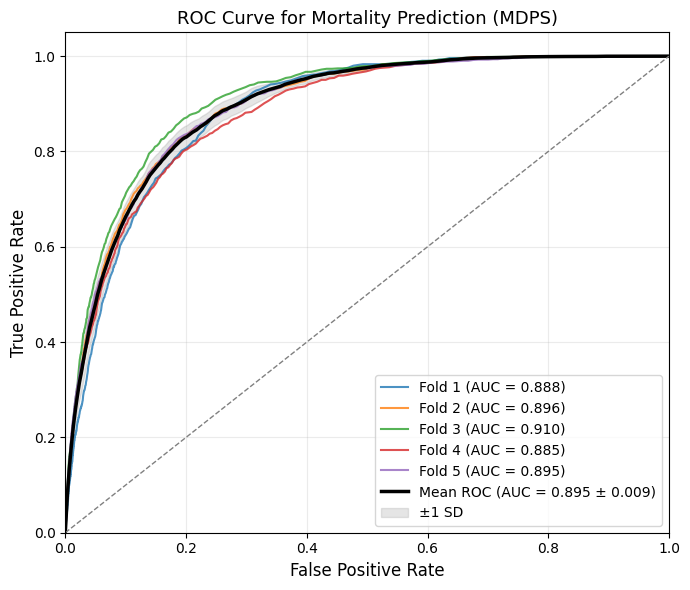

In [5]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/CoreBehrt_OOT/MDPS/3_Holdout/Mortality/Predictions/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDPS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDPS, "MDPS", "Mortality")

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


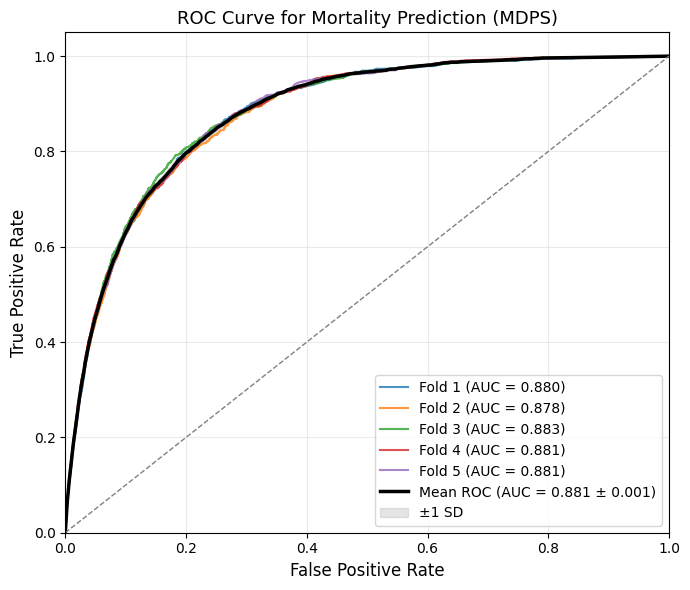

In [18]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/Xgboost_OOT/MDPS/Mortality/Evalutation/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDPS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDPS, "MDPS", "Mortality")

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


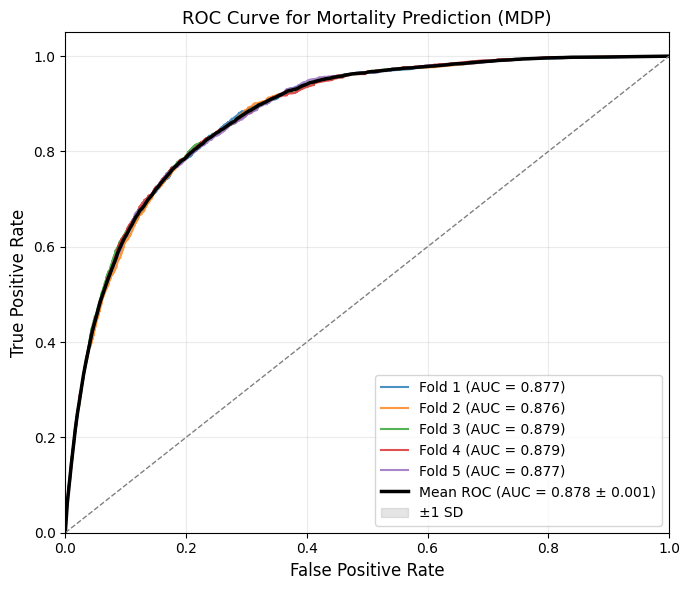

In [17]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/Xgboost_OOT/MDP/Mortality/Evalutation/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDP = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDP, "MDP", "Mortality")

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


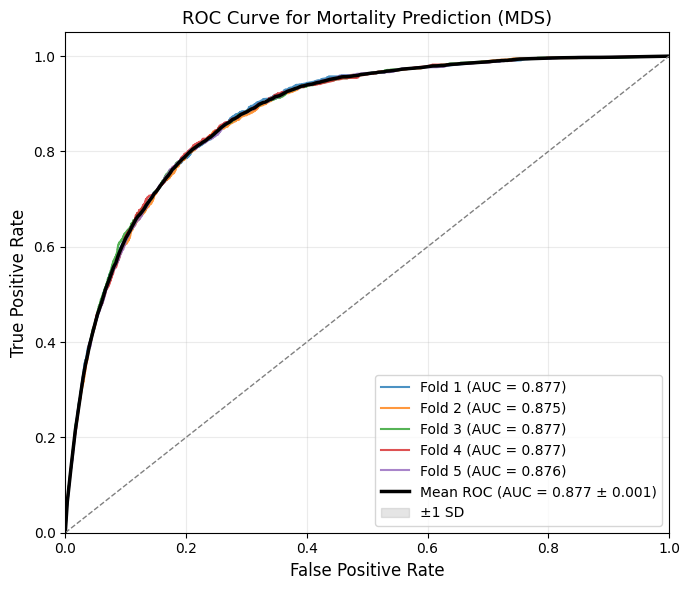

In [16]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/Xgboost_OOT/MDS/Mortality/Evalutation/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDS, "MDS", "Mortality")

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


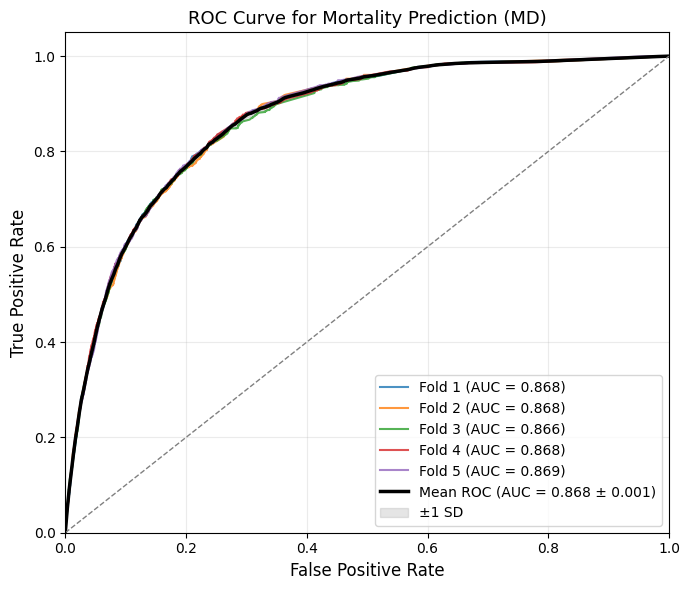

In [15]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/Xgboost_OOT/MD/Mortality/Evalutation/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MD = dataset.to_pandas_dataframe()
plot_cv_roc(df_MD, "MD", "Mortality")

In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

def compute_cv_roc(df):

    fold_cols = [col for col in df.columns if "fold" in col]

    mean_fpr = np.linspace(0, 1, 500)
    tprs = []
    aucs = []

    for col in fold_cols:

        sub_df = df[["target", col]].dropna()

        y_true = sub_df["target"].astype(int).values
        y_score = sub_df[col].values

        # sanity check
        if len(np.unique(y_true)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    return mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc

In [24]:
from azureml.core import Dataset
import pandas as pd

def load_single_csv(datastore, path):

    dataset = Dataset.Tabular.from_delimited_files(
        path=(datastore, path)
    )

    df = dataset.to_pandas_dataframe()

    return df

In [48]:
def plot_multi_model_roc_clean(model_configs, datastore):

    plt.figure(figsize=(7.5, 6.5))
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    results = {}

    for i, config in enumerate(model_configs):

        name = config["name"]
        path = config["path"]

        df = load_single_csv(datastore, path)

        mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc = compute_cv_roc(df)

        results[name] = (mean_auc, std_auc)

        plt.plot(
            mean_fpr,
            mean_tpr,
            color=colors[i],
            lw=2.5,
            label=f"{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})"
        )

    plt.plot([0,1],[0,1],'--',color='grey')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Comparison")

    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.show()

    return results

In [58]:
def plot_publication_roc(model_results, highlight="MDP"):

    plt.figure(figsize=(6.5, 6))

    # رنگ‌های واضح‌تر و حرفه‌ای‌تر (colorblind-friendly)
    colors = {
        "MD": "#1f77b4",    # blue
        "MDP": "#d62728",   # red (highlight)
        "MDS": "#2ca02c",   # green
        "MDPS": "#9467bd"   # purple
    }

    for name, (fpr, tpr, std_tpr, auc_mean, auc_std) in model_results.items():

        if name == highlight:
            plt.plot(
                fpr, tpr,
                color=colors[name],
                lw=3.2,
                label=f"{name} (AUC = {auc_mean:.3f})",
                zorder=3
            )

            # shading فقط برای مدل اصلی
            plt.fill_between(
                fpr,
                np.maximum(tpr - std_tpr, 0),
                np.minimum(tpr + std_tpr, 1),
                color=colors[name],
                alpha=0.15
            )

        else:
            plt.plot(
                fpr, tpr,
                color=colors[name],
                lw=2.0,
                alpha=0.9,
                label=f"{name} ({auc_mean:.3f})",
                zorder=2
            )

    # baseline
    plt.plot([0,1],[0,1], '--', color='grey', lw=1)

    # 🔍 zoom روی بخش مهم
    plt.xlim(0, 0.3)
    plt.ylim(0.7, 1.0)

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)

    plt.title("ROC Curve Comparison", fontsize=13)

    plt.legend(frameon=False, fontsize=10)
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [51]:
def make_results_table(results_dict):

    df = pd.DataFrame([
        {"Model": k, "AUC (mean ± std)": f"{v[0]:.3f} ± {v[1]:.3f}"}
        for k, v in results_dict.items()
    ])

    return df

In [20]:


model_configs = [
    {
        "name": "MD",
        "path": "Zahra/032026/Xgboost_OOT/MD/Mortality/Evalutation/predictions.csv"
    },
    {
        "name": "MDP",
        "path": "Zahra/032026/Xgboost_OOT/MDP/Mortality/Evalutation/predictions.csv"
    },
    {
        "name": "MDS",
        "path": "Zahra/032026/Xgboost_OOT/MDS/Mortality/Evalutation/predictions.csv"
    },
    {
        "name": "MDPS",
        "path": "Zahra/032026/Xgboost_OOT/MDPS/Mortality/Evalutation/predictions.csv"
    }
]

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


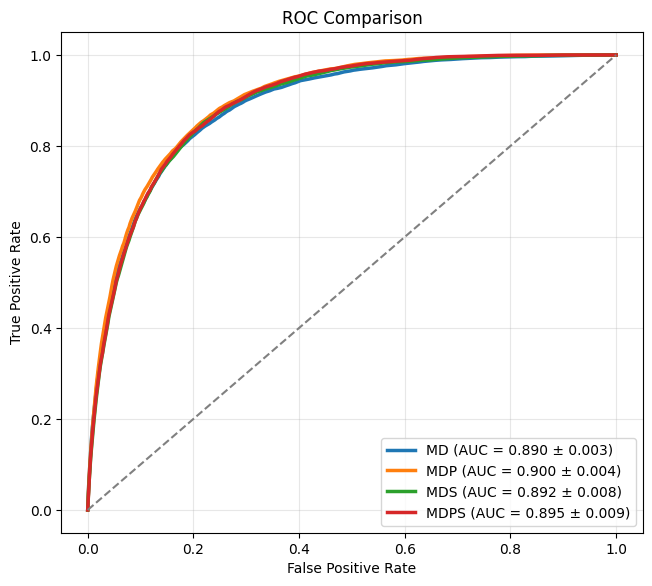

  Model AUC (mean ± std)
0    MD    0.890 ± 0.003
1   MDP    0.900 ± 0.004
2   MDS    0.892 ± 0.008
3  MDPS    0.895 ± 0.009


In [52]:
results = plot_multi_model_roc_clean(model_configs, datastore)

table = make_results_table(results)
print(table)


In [26]:
def build_model_results(model_configs, datastore):

    model_results = {}

    for config in model_configs:

        name = config["name"]
        path = config["path"]

        df = load_single_csv(datastore, path)

        mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc = compute_cv_roc(df)

        model_results[name] = (
            mean_fpr,
            mean_tpr,
            std_tpr,
            mean_auc,
            std_auc
        )

    return model_results

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assig

/tmp/ipykernel_10153/1945066815.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


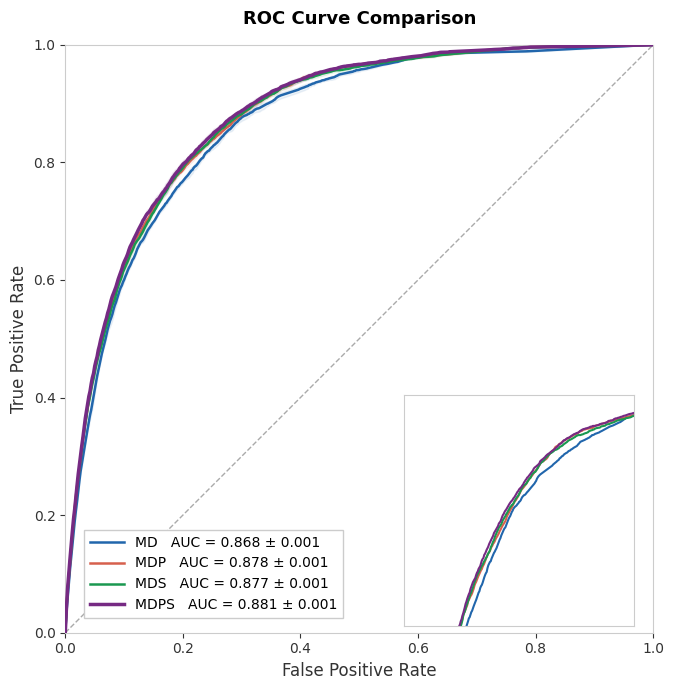

NameError: name 'make_results_table' is not defined

In [28]:
model_results = build_model_results(model_configs, datastore)

plot_publication_roc(model_results)

table = make_results_table({
    k: (v[3], v[4]) for k, v in model_results.items()
})

print(table)


In [36]:
print("Unique targets:", np.unique(df_MDP["target"]))
print("Shape:", df_MDP["target"].shape)
print("Type:", type(df_MDP["target"]))

for col in df_MDP.columns:
    if "fold" in col:
        print(col, df_MDP[col].shape)

Unique targets: [False  True]
Shape: (97264,)
Type: <class 'pandas.core.series.Series'>
fold_1_probas (97264,)
fold_2_probas (97264,)
fold_3_probas (97264,)
fold_4_probas (97264,)
fold_5_probas (97264,)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ---------- انتخاب بهترین مدل ----------
def get_best_model(model_results):
    return max(model_results.items(), key=lambda x: x[1][3])[0]


import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def get_best_model(model_results):
    return max(model_results.items(), key=lambda x: x[1][3])[0]

def plot_publication_roc(model_results):
    best_model = get_best_model(model_results)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    colors = {
        "MD":   "#2166AC",
        "MDP":  "#D6604D",
        "MDS":  "#1A9850",
        "MDPS": "#762A83"
    }
    
    # رسم curve ها
    for name, (fpr, tpr, std_tpr, auc_mean, auc_std) in model_results.items():
        tpr = np.clip(tpr, 0, 1)
        upper = np.clip(tpr + std_tpr, 0, 1)
        lower = np.clip(tpr - std_tpr, 0, 1)
        lw = 2.5 if name == best_model else 1.8
        ax.plot(
            fpr, tpr,
            color=colors[name], lw=lw,
            label=f"{name}   AUC = {auc_mean:.3f} ± {auc_std:.3f}",
            zorder=3
        )
        ax.fill_between(fpr, lower, upper, color=colors[name], alpha=0.08, zorder=2)
    
    # خط diagonal
    ax.plot([0, 1], [0, 1], '--', color='#AAAAAA', lw=1, zorder=1)
    
    # legend - وسط چپ
    legend = ax.legend(
        loc='center left',
        bbox_to_anchor=(0.02, 0.10),
        fontsize=10,
        framealpha=1.0,
        edgecolor='#CCCCCC',
        fancybox=False,
        handlelength=2.5,
    )
    
    # zoom - گوشه راست پایین
    axins = inset_axes(
        ax, width="40%", height="40%",
        loc="lower right",
        bbox_to_anchor=(0.0, 0.0, 0.98, 0.98),
        bbox_transform=ax.transAxes
    )
    axins.set_facecolor('white')
    axins.set_xticks([])
    axins.set_yticks([])
    axins.tick_params(left=False, bottom=False)
    for name, (fpr, tpr, _, _, _) in model_results.items():
        axins.plot(fpr, tpr, color=colors[name], lw=1.5)
    axins.set_xlim(0.03, 0.6)
    axins.set_ylim(0.75, 1)
    #axins.set_xticks([0.0, 0.1, 0.2])
    #axins.set_yticks([0.8, 0.9, 1.0])
    #axins.tick_params(labelsize=7)
   # axins.set_title("Zoom", fontsize=8, color='#444444')
    for spine in axins.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.8)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate", fontsize=12, color='#333333')
    ax.set_ylabel("True Positive Rate", fontsize=12, color='#333333')
    ax.set_title("ROC Curve Comparison", fontsize=13, fontweight='bold', pad=15)
    ax.tick_params(labelsize=10, colors='#333333')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.8)
    
    ax.set_aspect('equal')  # این رو اضافه کن
    plt.tight_layout()
    plt.savefig('roc_nature.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

In [21]:
# مرحله 1: ساخت نتایج
model_results = build_model_results(model_configs, datastore)

# مرحله 2: رسم
plot_publication_roc (model_results)

# مرحله 3: جدول
table = make_results_table({
    k: (v[3], v[4]) for k, v in model_results.items()
})

print(table)

NameError: name 'build_model_results' is not defined